# Goal 1：真实开发数据、基线门控与独立审核

教师映射：`task1/作业/作业/作业1轨迹数据预处理.ipynb` → 本工作版。教师文件未修改。这里只报告本轮数据结构及明确的工程检查；真实米制三步链因 datum/距离口径与去噪删除调度未知而 **BLOCKED**。没有合成输入替代真实处理，没有方法最优结论。

In [1]:
from pathlib import Path
import json, sys
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p/'AGENTS.md').exists())
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from task1.workflow.io import DATA, CONFIG, EVIDENCE, read_json, digest
from task1.workflow.diagnostics import profile, aggregate, time_boundaries, independent_profile_review
from task1.workflow.tools import execute_tool
policy=read_json(CONFIG); pilot=read_json(ROOT/'task1/config/pilot.json')
assert digest(DATA)==policy['raw_sha256']==pilot['raw_sha256']
raw=read_json(DATA)
print('模式：RECOMPUTE；本次模型调用：0')
print('原始输入 SHA256:', digest(DATA))
print('固定开发样本:', pilot['ids'])

模式：RECOMPUTE；本次模型调用：0
原始输入 SHA256: c59be4c079d2ffd8ae0127c8a361c77ba277252abb2c7202efb9ee4e8e6084d3
固定开发样本: ['0', '1', '2', '246', '256', '306', '352']


## 数据口径与固定样本
Unix 秒与 (lon,lat) 度为补充讲义声明；CRS UNKNOWN。7例属于开发暴露，无最终留出冻结。下列代码实际读取原始JSON并重算，未读旧CSV替代计算。

In [2]:
rows=[profile(k,raw[k]) for k in pilot['ids']]
summary=aggregate(rows)
print(json.dumps({k:v for k,v in summary.items() if k!='dt_counts'},ensure_ascii=False,indent=2))

{
  "n_records": 7,
  "valid_structure_records": 7,
  "n_points": 783,
  "n_timestamps": 783,
  "invalid_timestamps": 0,
  "invalid_coordinates": 0,
  "negative_dt": 0,
  "zero_dt": 122,
  "positive_dt": 654,
  "same_time_different_position": 62,
  "consecutive_duplicate_position": 323,
  "long_gap_gt_30_source_seconds": 5,
  "edges_total": 776,
  "dt_computable": 776,
  "position_pairs_computable": 776,
  "point_count_min": 97,
  "point_count_max": 170,
  "modifications": 0,
  "physical_distance": {
    "value": null,
    "reason": "CRS_AND_DISTANCE_POLICY_UNRESOLVED"
  }
}


## 三步参考链与当前阻断
顺序来自基础 Notebook：分段/过滤→方向去噪→DP。65/5/30/400/35/5 是 STARTER_REFERENCE。完整真实链目前不会投影、删点、平滑或改时间；结构化结果保留全部输入为 not_processed。

In [3]:
baseline=execute_tool('baseline',pilot['ids'],policy)
assert baseline['status']=='BLOCKED'
assert baseline['modified_values']==0
assert baseline['stage_counts']['not_processed']==summary['n_points']
print(json.dumps(baseline,ensure_ascii=False,indent=2))

{
  "classification": "CURRENT_RUN_REAL_DATA",
  "input_sha256": "c59be4c079d2ffd8ae0127c8a361c77ba277252abb2c7202efb9ee4e8e6084d3",
  "record_ids": [
    "0",
    "1",
    "2",
    "246",
    "256",
    "306",
    "352"
  ],
  "input_records": 7,
  "input_points": 783,
  "modified_values": 0,
  "parent_version": "RAW:c59be4c079d2ffd8ae0127c8a361c77ba277252abb2c7202efb9ee4e8e6084d3",
  "semantics_version": "g1-semantics-v1",
  "metrics_version": "g1-metrics-v1",
  "status": "BLOCKED",
  "reason": [
    "D1_COORDINATE_DATUM_UNKNOWN",
    "D1_DISTANCE_CONTRACT_UNAPPROVED",
    "D2_DIRECTION_SCHEDULE_UNAPPROVED",
    "REAL_INPUT_CONTRACT_AND_ADAPTER_NOT_REGISTERED"
  ],
  "stage_counts": {
    "input": 783,
    "segmented": null,
    "filtered": null,
    "denoised": null,
    "simplified": null,
    "not_processed": 783
  },
  "unavailable_metrics_reason": "D1_COORDINATE_DATUM_UNKNOWN; D1_DISTANCE_CONTRACT_UNAPPROVED; D2_DIRECTION_SCHEDULE_UNAPPROVED; REAL_INPUT_CONTRACT_AND_ADAPTER_NOT_

## 允许的真实时间诊断
独立于未知CRS：严格 dt>30 秒（以及负dt）标边界，右点归新片段；这不是完整的时空分段/长度过滤。零dt并不被填成0速度，不删除重复位置。

In [4]:
parts=[time_boundaries(k,raw[k],30) for k in pilot['ids']]
assert all(p['n_accounted']==p['n_input'] and p['modified']==0 and p['deleted']==0 for p in parts)
for p in parts: print(p['record_id'], 'input=',p['n_input'], 'time-only partitions=',len(p['partitions']), 'cuts=',len(p['cuts']))

0 input= 99 time-only partitions= 1 cuts= 0
1 input= 97 time-only partitions= 1 cuts= 0
2 input= 99 time-only partitions= 1 cuts= 0
246 input= 108 time-only partitions= 1 cuts= 0
256 input= 99 time-only partitions= 1 cuts= 0
306 input= 111 time-only partitions= 5 cuts= 4
352 input= 170 time-only partitions= 2 cuts= 1


## 独立审核与已保存结果比较
独立计数实现不调用 profile；与本轮保存的原始结构诊断逐对象比对。工程有效与质量接受分开。

In [5]:
review=independent_profile_review({k:raw[k] for k in pilot['ids']},rows)
assert review['status']=='VERIFIED'
stored=read_json(ROOT/'task1/results/goal1/pilot_diagnostics.json')
assert rows==stored['profiles']
assert parts==stored['time_boundaries']
assert digest(DATA)==policy['raw_sha256']
print(review)
print('与保存记录重算一致；真实三步处理仍 BLOCKED。')

{'status': 'VERIFIED', 'errors': [], 'records_checked': 7, 'claim': 'Structural counts only; no physical accuracy or cleaning quality claim'}
与保存记录重算一致；真实三步处理仍 BLOCKED。


## 本轮必要图与限制
图仅编码7条开发记录原始相邻边的诊断计数，不是清洗前后图；无CRS推断、无底图。有限线段/DP/方向关系反例属于独立测试中的 CONSTRUCTED_FIXTURE，不属于本Notebook的真实轨迹结果。

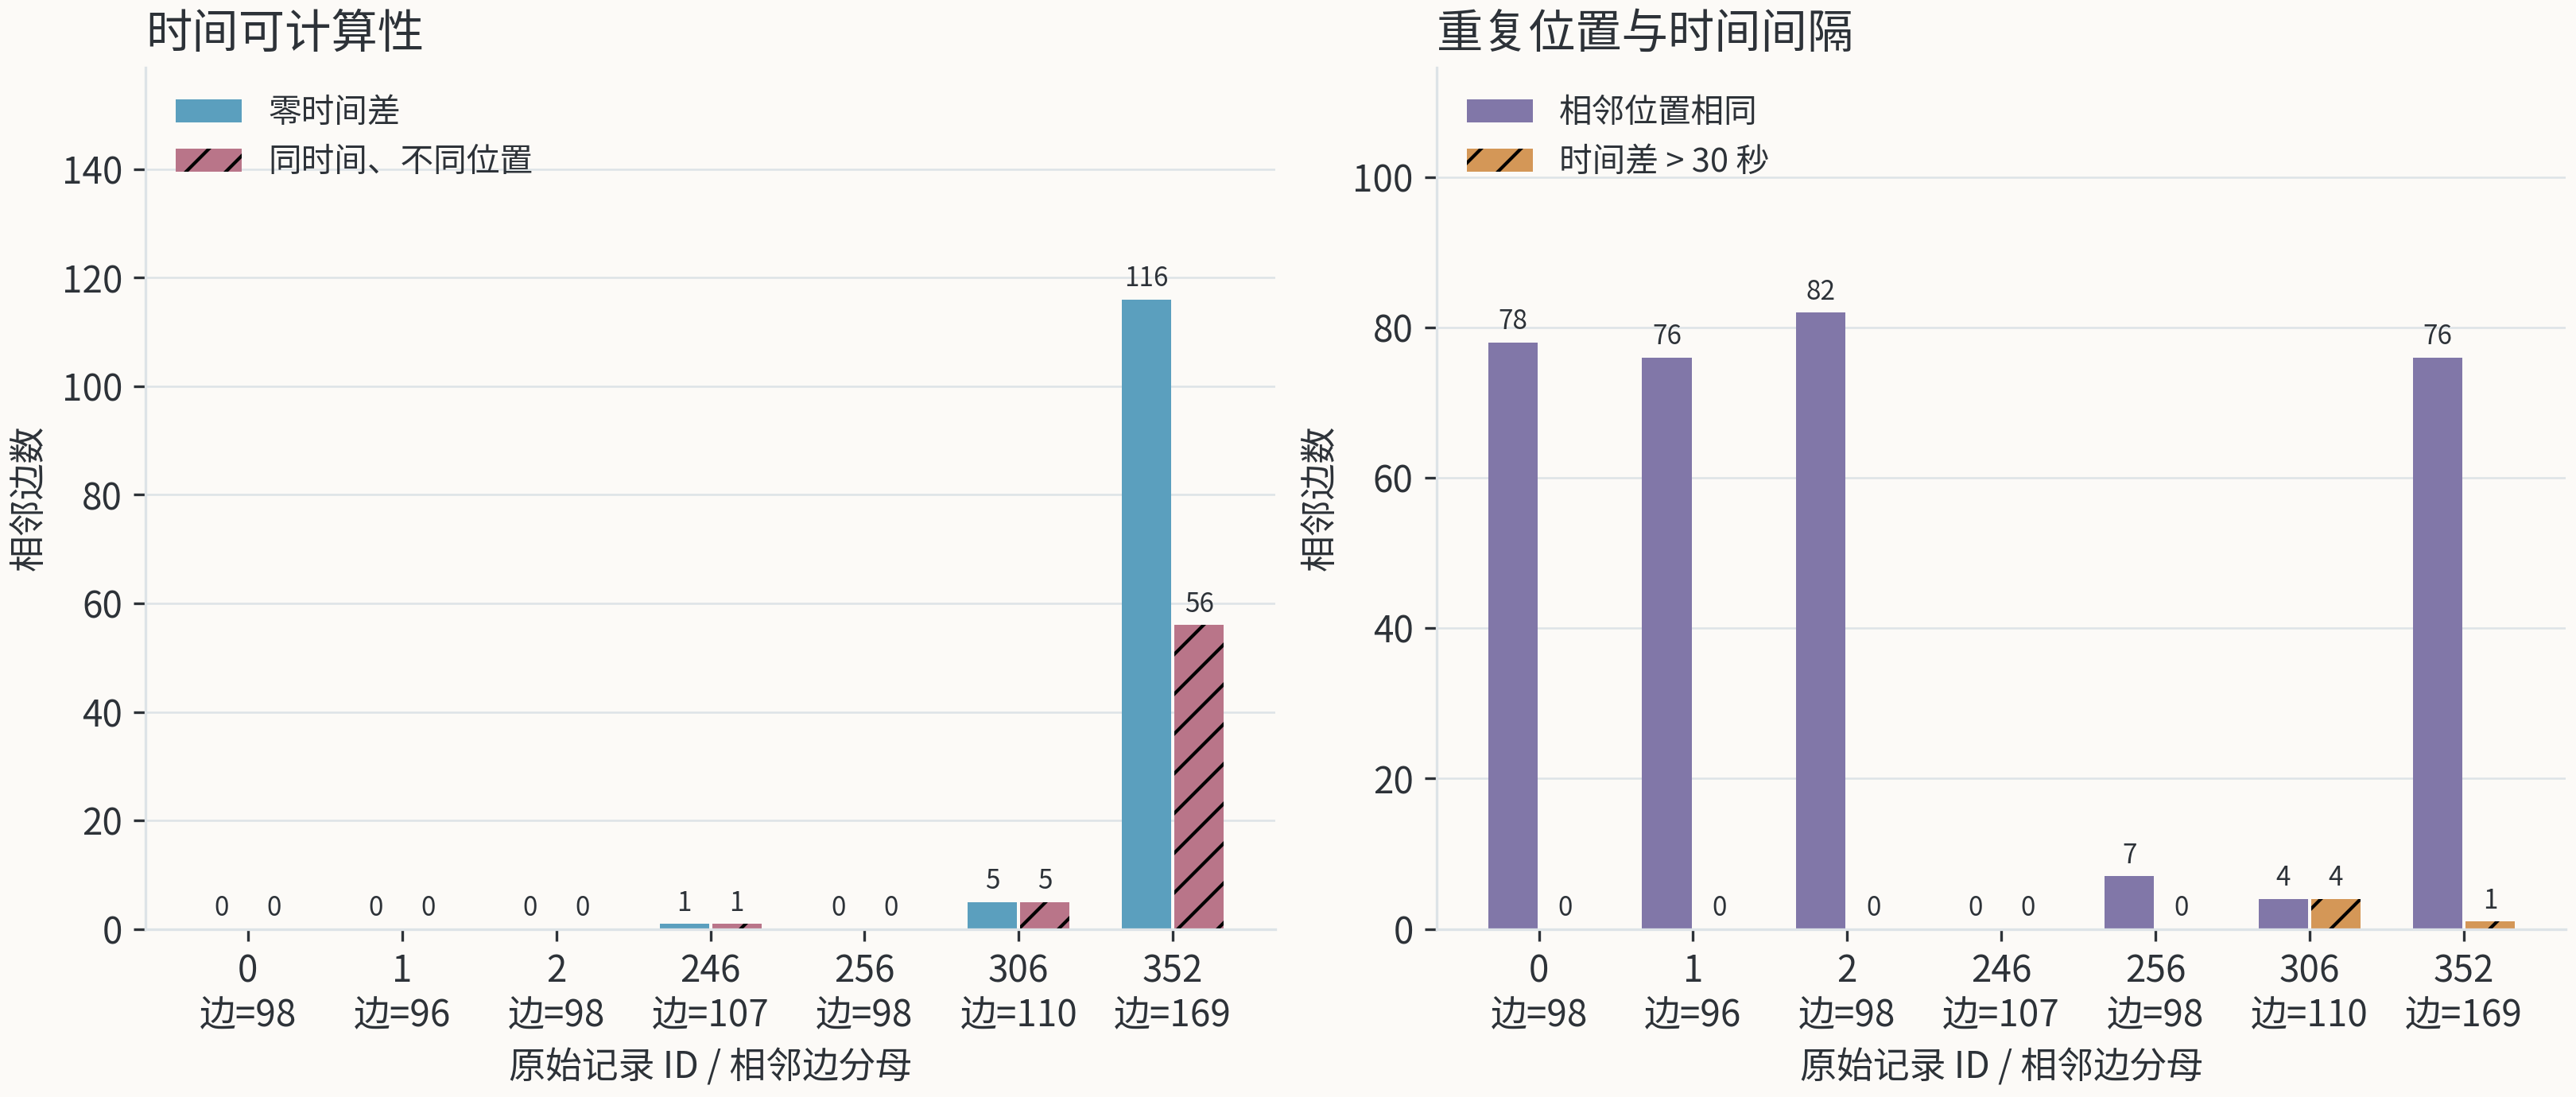

In [6]:
from IPython.display import display, Image
display(Image(filename=str(ROOT/'task1/figures/goal1/pilot_diagnostics.png')))

## SC-LAB1-G1-REPAIR-001 当前修复复算
以下为当前代码重新读取教师 JSON 的诊断；旧 run03 的 REPLAY 单独保留。构造处理链测试不代表真实数据已清洗。

In [7]:
revision=EVIDENCE/'revisions/SC-LAB1-G1-REPAIR-001'
current=execute_tool('profile_pilot',pilot['ids'],policy)
stored=read_json(revision/'results/profile_pilot.json')
assert current==stored
checked=execute_tool('recompute_check',pilot['ids'],policy,current['result']['profiles'])
assert checked['status']=='VERIFIED' and checked['result']['exact_match']
print('当前7条 / 783点复算一致；模型调用0；完整baseline仍BLOCKED')

当前7条 / 783点复算一致；模型调用0；完整baseline仍BLOCKED


## 本批 LIVE 的真实边界
只读取回执，不调用模型。有效模型响应、数值工具与完整反馈分别按实际产物计数；没有发生的角色不得补写。

In [8]:
budget=read_json(EVIDENCE/'runs/budget_repair_001.json')
print(json.dumps(budget,ensure_ascii=False,indent=2))
new_run=revision/'runs/g1-repair-roles-01/manifest.json'
print(read_json(new_run) if new_run.exists() else '角色链NOT_RUN：连通性探针没有通过')
assert digest(DATA)==policy['raw_sha256']

{
  "batch": "SC-LAB1-G1-REPAIR-001",
  "authorization_sha256": "541c4106fd7fde37feaf6251e1156987b55a674b9bec90fea68195f93c2082cb",
  "old_ledger_sha256": "346dbbf5457964ed7d387d5fdbda458ef21f060b684ff4bdde93b25087661e29",
  "old_model_attempts": 4,
  "model_attempts": 6,
  "tool_requests": 5,
  "probe_passed": true,
  "calls": {
    "g1-repair-connectivity-01-probe": {
      "run_id": "g1-repair-connectivity-01",
      "reserved_at": "2026-09-26T13:21:56.620808+00:00",
      "probe": true,
      "status": "VERIFIED_STRUCTURE_ONLY",
      "process_started": true,
      "completed_turns": 1,
      "visible_counts": {
        "reconnect_notifications": 0,
        "fallback_notifications": 0,
        "sampling_retry_lines": 0,
        "underlying_requests": "unknown"
      }
    },
    "g1-repair-roles-01-01-research": {
      "run_id": "g1-repair-roles-01",
      "reserved_at": "2026-09-26T13:22:08.968690+00:00",
      "probe": false,
      "status": "VERIFIED_STRUCTURE_ONLY",
      "pro

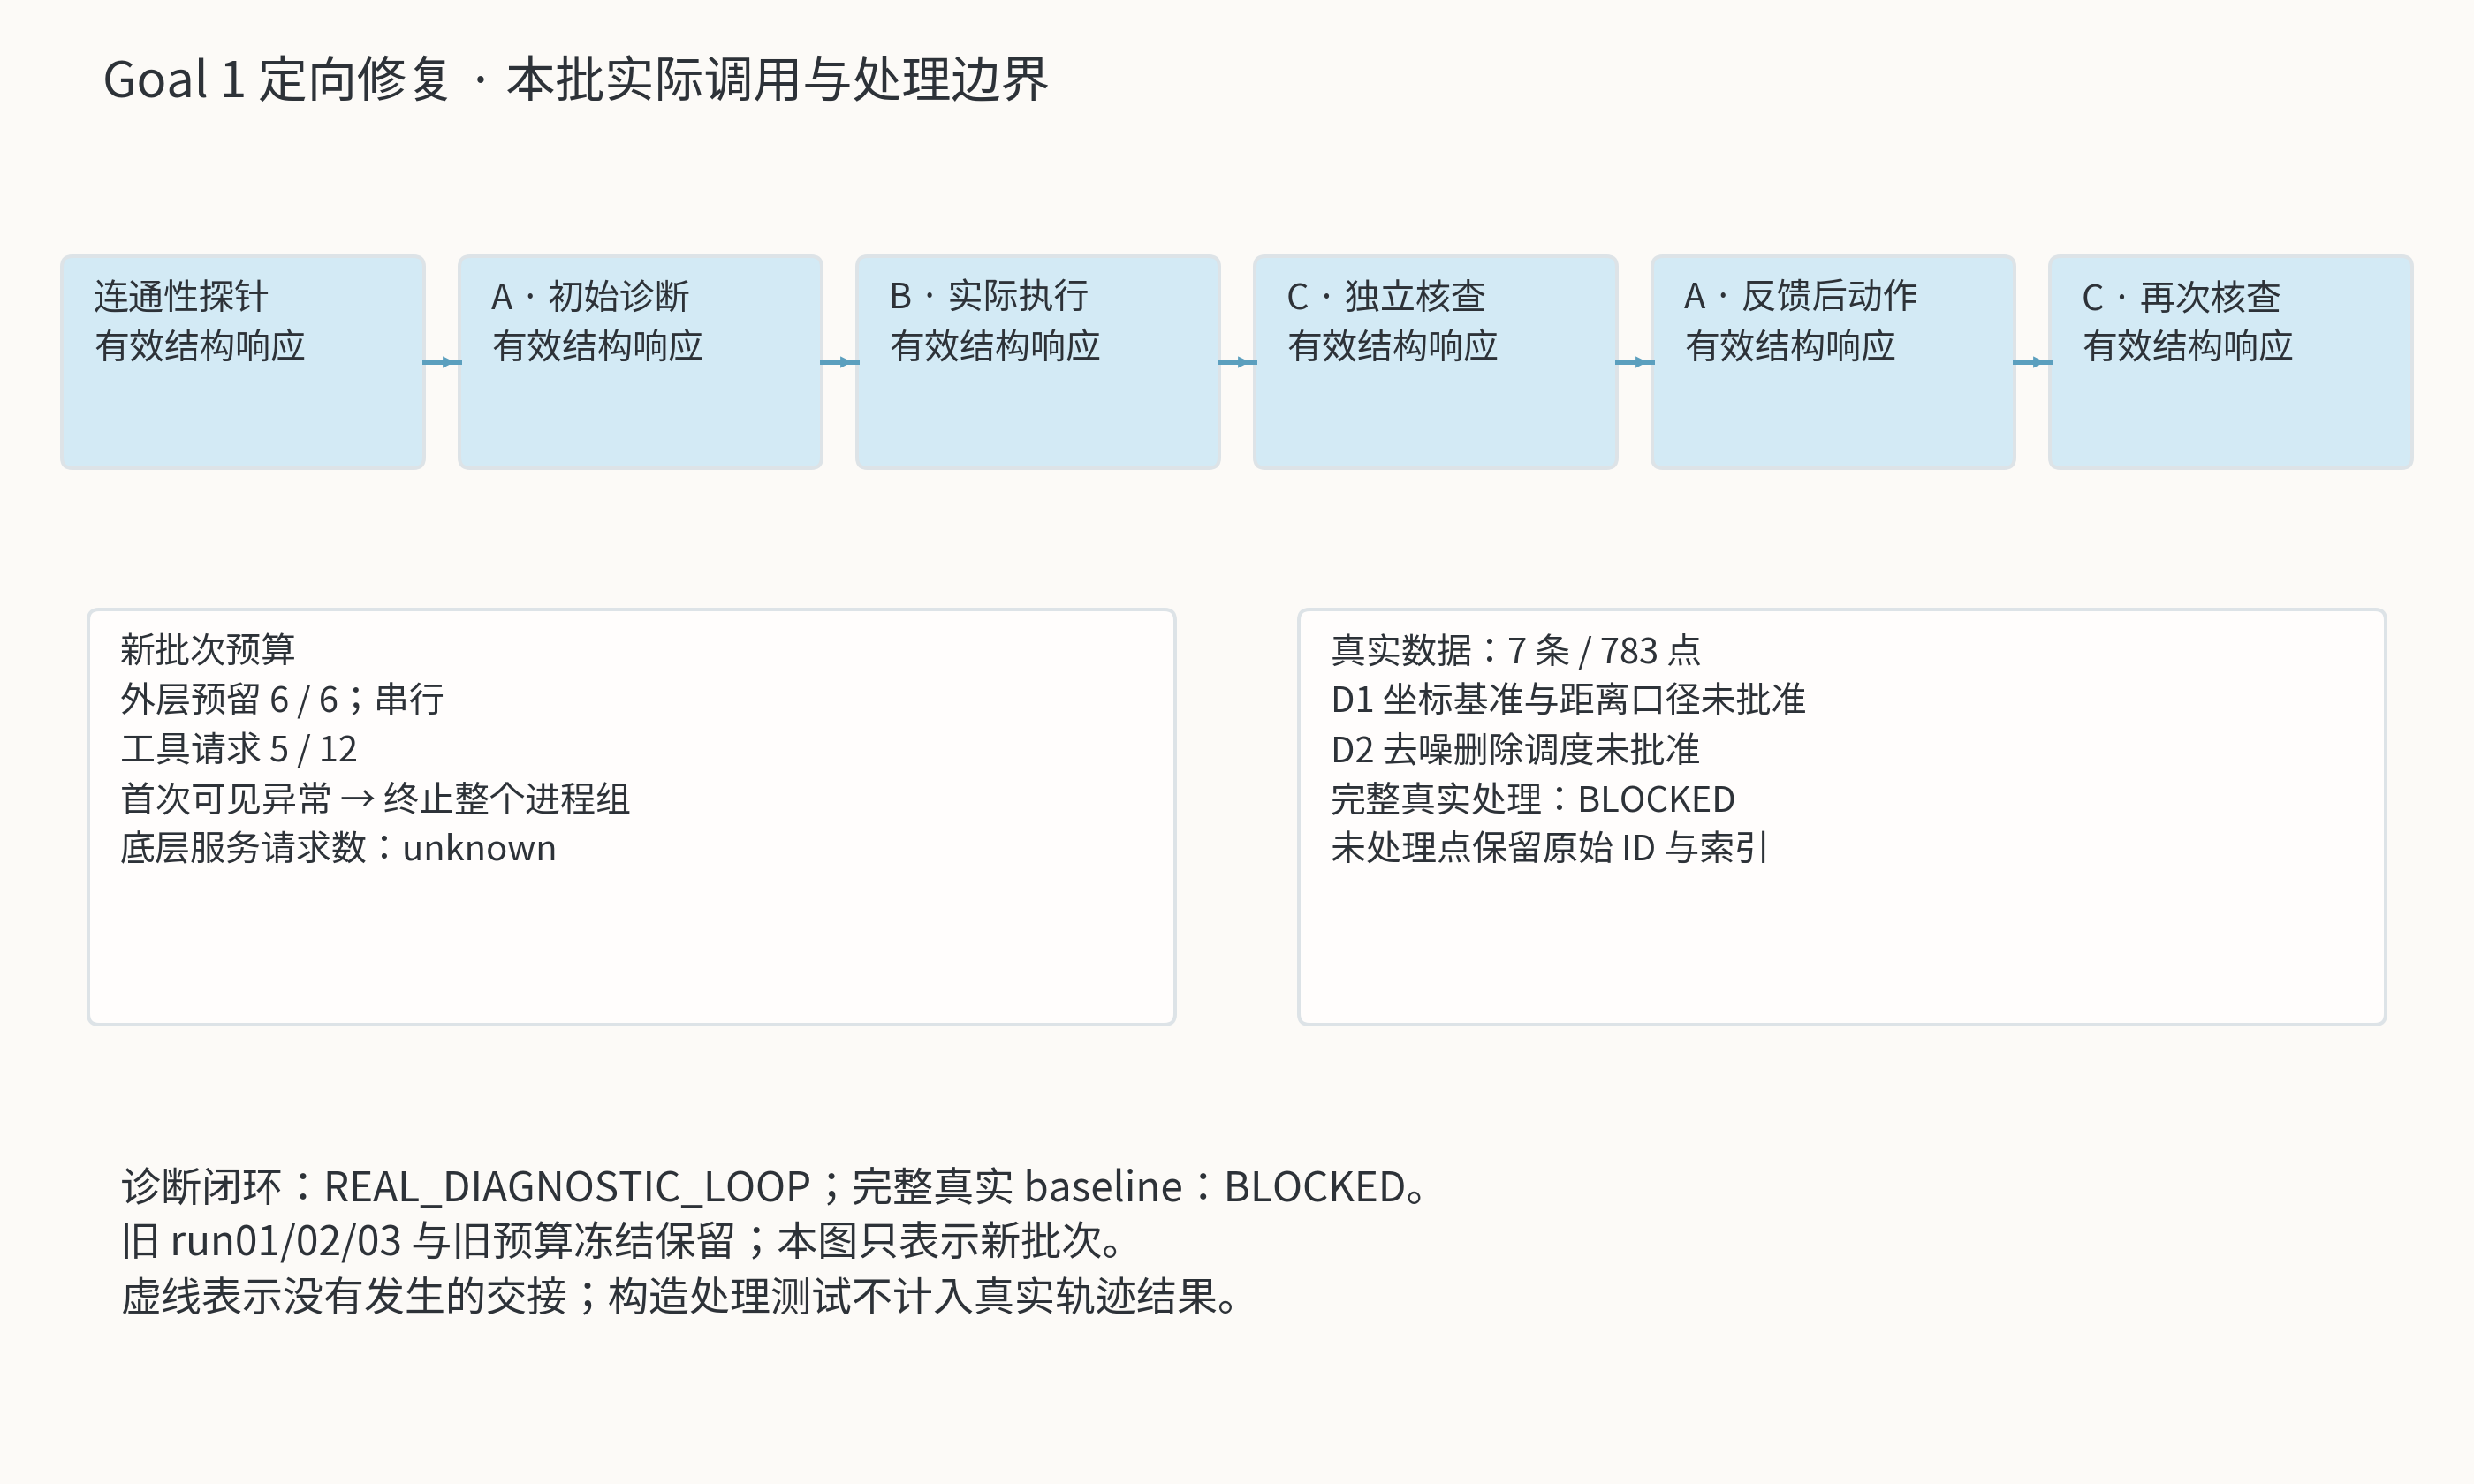

In [9]:
from IPython.display import display, Image
display(Image(filename=str(revision/'figures/repair_loop.png')))